In [1]:
import torch
import numpy as np
import pandas as pd
import cv2
import shapely

print("All packages loaded successfully")
print("Torch version:", torch.__version__)

All packages loaded successfully
Torch version: 2.8.0


In [1]:
import sys
!{sys.executable} model/OOD_classification_baseline_unweighted.py

Loading OOD data...

Using environment column for per environment analysis: disaster

Split sizes:
split
OOD_train    166544
OOD_hold      53403
OOD_test      46833
Name: count, dtype: int64

Train label distribution:
damage_label
no-damage       120576
major-damage     17327
minor-damage     17063
destroyed        11578
Name: count, dtype: int64

OOD validation label distribution:
damage_label
no-damage       37859
destroyed        6089
major-damage     2260
minor-damage      625
Name: count, dtype: int64

OOD hold label distribution:
damage_label
no-damage       38388
minor-damage     8428
destroyed        3558
major-damage     3029
Name: count, dtype: int64

Train environments:
['hurricane-harvey', 'hurricane-matthew', 'mexico-earthquake', 'palu-tsunami']

OOD validation environments:
['guatemala-volcano', 'hurricane-florence', 'midwest-flooding', 'santa-rosa-wildfire']

OOD hold environments:
['hurricane-michael', 'socal-fire']

Image overlap check:
OOD_train intersection OOD_val: 


Loaded rows: 267015

Seeds loaded:
[42, 123, 999, 2024, 2025]

Rows per seed:
seed
42      53403
123     53403
999     53403
2024    53403
2025    53403
Name: count, dtype: int64

Pooled normalized confusion matrix:

              no-damage  minor-damage  major-damage  destroyed
no-damage         0.803         0.142         0.042      0.013
minor-damage      0.593         0.316         0.060      0.031
major-damage      0.465         0.346         0.117      0.073
destroyed         0.312         0.370         0.157      0.161


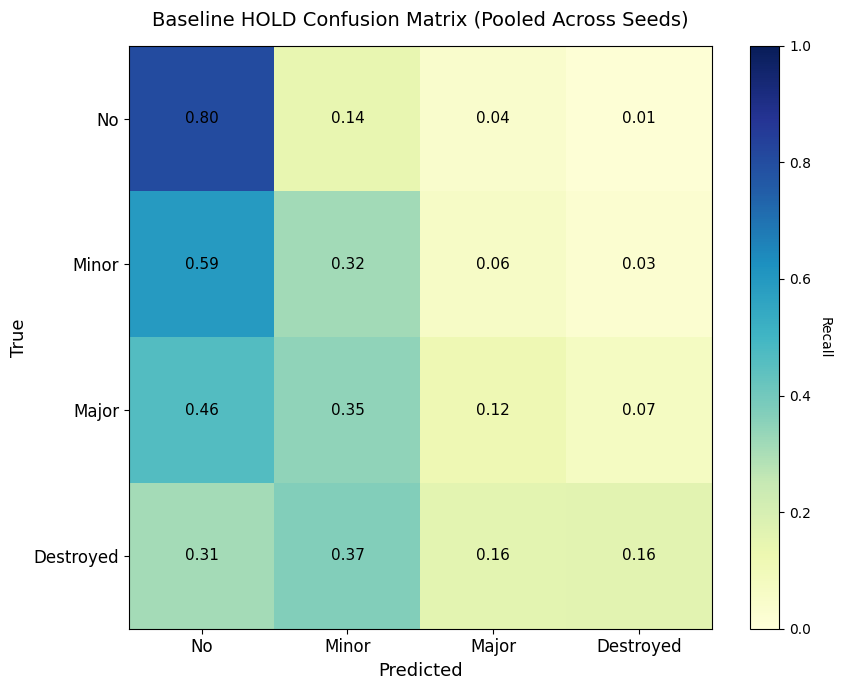

In [11]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix

# ============================================================
# Configuration
# ============================================================

SEEDS = [42, 123, 999, 2024, 2025]

labels = [
    "no-damage",
    "minor-damage",
    "major-damage",
    "destroyed",
]

short_labels = [
    "No",
    "Minor",
    "Major",
    "Destroyed",
]

BASE_DIR = (
    Path.home()
    / "Desktop"
    / "OOD_training_outputs"
    / "unweighted_baseline_resnet50_5seeds_1se"
)

# ============================================================
# Load all seed prediction files
# ============================================================

dfs = []

for seed in SEEDS:

    pred_path = (
        BASE_DIR
        / f"seed_{seed}"
        / "ood_hold_predictions_selected_1se.csv"
    )

    if not pred_path.exists():
        raise FileNotFoundError(
            f"Missing prediction file: {pred_path}"
        )

    df_seed = pd.read_csv(pred_path)

    df_seed["seed"] = seed

    dfs.append(df_seed)

# ============================================================
# Concatenate all predictions
# ============================================================

df = pd.concat(dfs, ignore_index=True)

print("\nLoaded rows:", len(df))

print("\nSeeds loaded:")
print(sorted(df["seed"].unique()))

print("\nRows per seed:")
print(df["seed"].value_counts().sort_index())

# ============================================================
# True / predicted labels
# ============================================================

y_true = df["target_id"]
y_pred = df["pred_id"]

# ============================================================
# Overall pooled confusion matrix
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1, 2, 3],
)

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

print("\nPooled normalized confusion matrix:\n")

print(
    pd.DataFrame(
        cm_norm,
        index=labels,
        columns=labels,
    ).round(3)
)

# ============================================================
# Plot
# ============================================================

fig, ax = plt.subplots(figsize=(9, 7))

im = ax.imshow(
    cm_norm,
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
)

# ============================================================
# Colorbar
# ============================================================

cbar = fig.colorbar(im, ax=ax)

cbar.ax.set_ylabel(
    "Recall",
    rotation=270,
    labelpad=15,
)

# ============================================================
# Axis labels
# ============================================================

ax.set_xticks(np.arange(len(short_labels)))
ax.set_yticks(np.arange(len(short_labels)))

ax.set_xticklabels(
    short_labels,
    fontsize=12,
)

ax.set_yticklabels(
    short_labels,
    fontsize=12,
)

ax.set_xlabel(
    "Predicted",
    fontsize=13,
)

ax.set_ylabel(
    "True",
    fontsize=13,
)

ax.set_title(
    "Baseline HOLD Confusion Matrix (Pooled Across Seeds)",
    fontsize=14,
    pad=15,
)

# ============================================================
# Cell annotations
# ============================================================

for i in range(cm_norm.shape[0]):

    for j in range(cm_norm.shape[1]):

        ax.text(
            j,
            i,
            f"{cm_norm[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=11,
            color="black",
        )

# ============================================================
# Final layout
# ============================================================

plt.tight_layout()
plt.show()

In [12]:
from pathlib import Path
import pandas as pd

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
)

# ============================================================
# Configuration
# ============================================================

SEEDS = [42, 123, 999, 2024, 2025]

DISASTER_NAME = "hurricane-michael"

BASE_DIR = (
    Path.home()
    / "Desktop"
    / "OOD_training_outputs"
    / "unweighted_baseline_resnet50_5seeds_1se"
)

# ============================================================
# Load all seeds
# ============================================================

dfs = []

for seed in SEEDS:

    pred_path = (
        BASE_DIR
        / f"seed_{seed}"
        / "ood_hold_predictions_selected_1se.csv"
    )

    if not pred_path.exists():
        raise FileNotFoundError(
            f"Missing prediction file: {pred_path}"
        )

    df_seed = pd.read_csv(pred_path)

    df_seed["seed"] = seed

    dfs.append(df_seed)

# ============================================================
# Concatenate
# ============================================================

df = pd.concat(dfs, ignore_index=True)

print("\nLoaded rows:", len(df))

# ============================================================
# Filter disaster
# ============================================================

subset = df[df["disaster"] == DISASTER_NAME].copy()

print(f"\nSamples in {DISASTER_NAME}: {len(subset)}")

# ============================================================
# Macro F1
# ============================================================

macro_f1 = f1_score(
    subset["target_id"],
    subset["pred_id"],
    average="macro",
)

print(f"\nMacro F1 ({DISASTER_NAME}): {macro_f1:.4f}")

# ============================================================
# Classification report
# ============================================================

print("\nClassification Report:\n")

print(
    classification_report(
        subset["target_id"],
        subset["pred_id"],
        digits=4,
        zero_division=0,
    )
)

# ============================================================
# Confusion matrix
# ============================================================

cm = confusion_matrix(
    subset["target_id"],
    subset["pred_id"],
    normalize="true",
)

print("\nNormalized Confusion Matrix:\n")

print(cm)


Loaded rows: 267015

Samples in hurricane-michael: 175635

Macro F1 (hurricane-michael): 0.3646

Classification Report:

              precision    recall  f1-score   support

           0     0.7240    0.7616    0.7424    113455
           1     0.3230    0.3185    0.3207     41460
           2     0.1754    0.1149    0.1388     14595
           3     0.2627    0.2504    0.2564      6125

    accuracy                         0.5855    175635
   macro avg     0.3713    0.3614    0.3646    175635
weighted avg     0.5677    0.5855    0.5757    175635


Normalized Confusion Matrix:

[[0.76164999 0.1800097  0.04109118 0.01724913]
 [0.59138929 0.31849976 0.05940666 0.03070429]
 [0.46831107 0.34313121 0.11490236 0.07365536]
 [0.25877551 0.36669388 0.12408163 0.25044898]]


In [13]:
from pathlib import Path
import pandas as pd

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
)

# ============================================================
# Configuration
# ============================================================

SEEDS = [42, 123, 999, 2024, 2025]

DISASTER_NAME = "hurricane-florence"

BASE_DIR = (
    Path.home()
    / "Desktop"
    / "OOD_training_outputs"
    / "unweighted_baseline_resnet50_5seeds_1se"
)

class_names = [
    "no-damage",
    "minor-damage",
    "major-damage",
    "destroyed",
]

# ============================================================
# Load OOD validation predictions across all seeds
# Florence is in OOD_test -> validation predictions
# ============================================================

dfs = []

for seed in SEEDS:

    pred_path = (
        BASE_DIR
        / f"seed_{seed}"
        / "ood_val_predictions_selected_1se.csv"
    )

    if not pred_path.exists():
        raise FileNotFoundError(
            f"Missing prediction file: {pred_path}"
        )

    df_seed = pd.read_csv(pred_path)
    df_seed["seed"] = seed

    dfs.append(df_seed)

df = pd.concat(dfs, ignore_index=True)

print("\nLoaded rows:", len(df))

print("\nSeeds loaded:")
print(sorted(df["seed"].unique()))

print("\nAvailable disaster names:")
print(sorted(df["disaster"].astype(str).unique()))

# ============================================================
# Filter Florence
# ============================================================

subset = df[
    df["disaster"]
    .astype(str)
    .str.strip()
    .str.lower()
    == DISASTER_NAME.lower()
].copy()

print(f"\nSamples in {DISASTER_NAME}: {len(subset)}")

if len(subset) == 0:
    raise ValueError(
        f"No samples found for disaster: {DISASTER_NAME}"
    )

# ============================================================
# Macro F1
# ============================================================

macro_f1 = f1_score(
    subset["target_id"],
    subset["pred_id"],
    average="macro",
    labels=[0, 1, 2, 3],
    zero_division=0,
)

print(f"\nPooled Macro F1 ({DISASTER_NAME}): {macro_f1:.4f}")

# ============================================================
# Classification report
# ============================================================

print("\nClassification Report:\n")

print(
    classification_report(
        subset["target_id"],
        subset["pred_id"],
        labels=[0, 1, 2, 3],
        target_names=class_names,
        digits=4,
        zero_division=0,
    )
)

# ============================================================
# Normalized confusion matrix
# ============================================================

cm = confusion_matrix(
    subset["target_id"],
    subset["pred_id"],
    labels=[0, 1, 2, 3],
    normalize="true",
)

print("\nNormalized Confusion Matrix:\n")
print(cm)

# ============================================================
# Pretty DataFrame version
# ============================================================

cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names,
)

print("\nConfusion Matrix DataFrame:\n")
print(cm_df.round(3))


Loaded rows: 234165

Seeds loaded:
[42, 123, 999, 2024, 2025]

Available disaster names:
['guatemala-volcano', 'hurricane-florence', 'midwest-flooding', 'santa-rosa-wildfire']

Samples in hurricane-florence: 53640

Pooled Macro F1 (hurricane-florence): 0.2991

Classification Report:

              precision    recall  f1-score   support

   no-damage     0.8588    0.6524    0.7415     42330
minor-damage     0.0296    0.1448    0.0492      1160
major-damage     0.3009    0.4679    0.3663      9745
   destroyed     0.0321    0.0519    0.0396       405

    accuracy                         0.6034     53640
   macro avg     0.3053    0.3293    0.2991     53640
weighted avg     0.7333    0.6034    0.6531     53640


Normalized Confusion Matrix:

[[0.65239783 0.1005906  0.23635719 0.01065438]
 [0.48362069 0.14482759 0.35689655 0.01465517]
 [0.39291945 0.1221139  0.46793227 0.01703438]
 [0.37037037 0.14074074 0.43703704 0.05185185]]

Confusion Matrix DataFrame:

              no-damage  mino

Available splits:
split
OOD_train    166544
OOD_hold      53403
OOD_test      46833
Name: count, dtype: int64

Rows in selected split: 53403
Rows in prediction file: 53403

Number of available images: 1191

First available image IDs:
image_id
hurricane-michael_00000470    261
socal-fire_00000806           243
hurricane-michael_00000513    236
socal-fire_00000902           232
hurricane-michael_00000527    230
Name: count, dtype: int64

Selected image_id: hurricane-michael_00000003
Number of buildings in selected image: 35


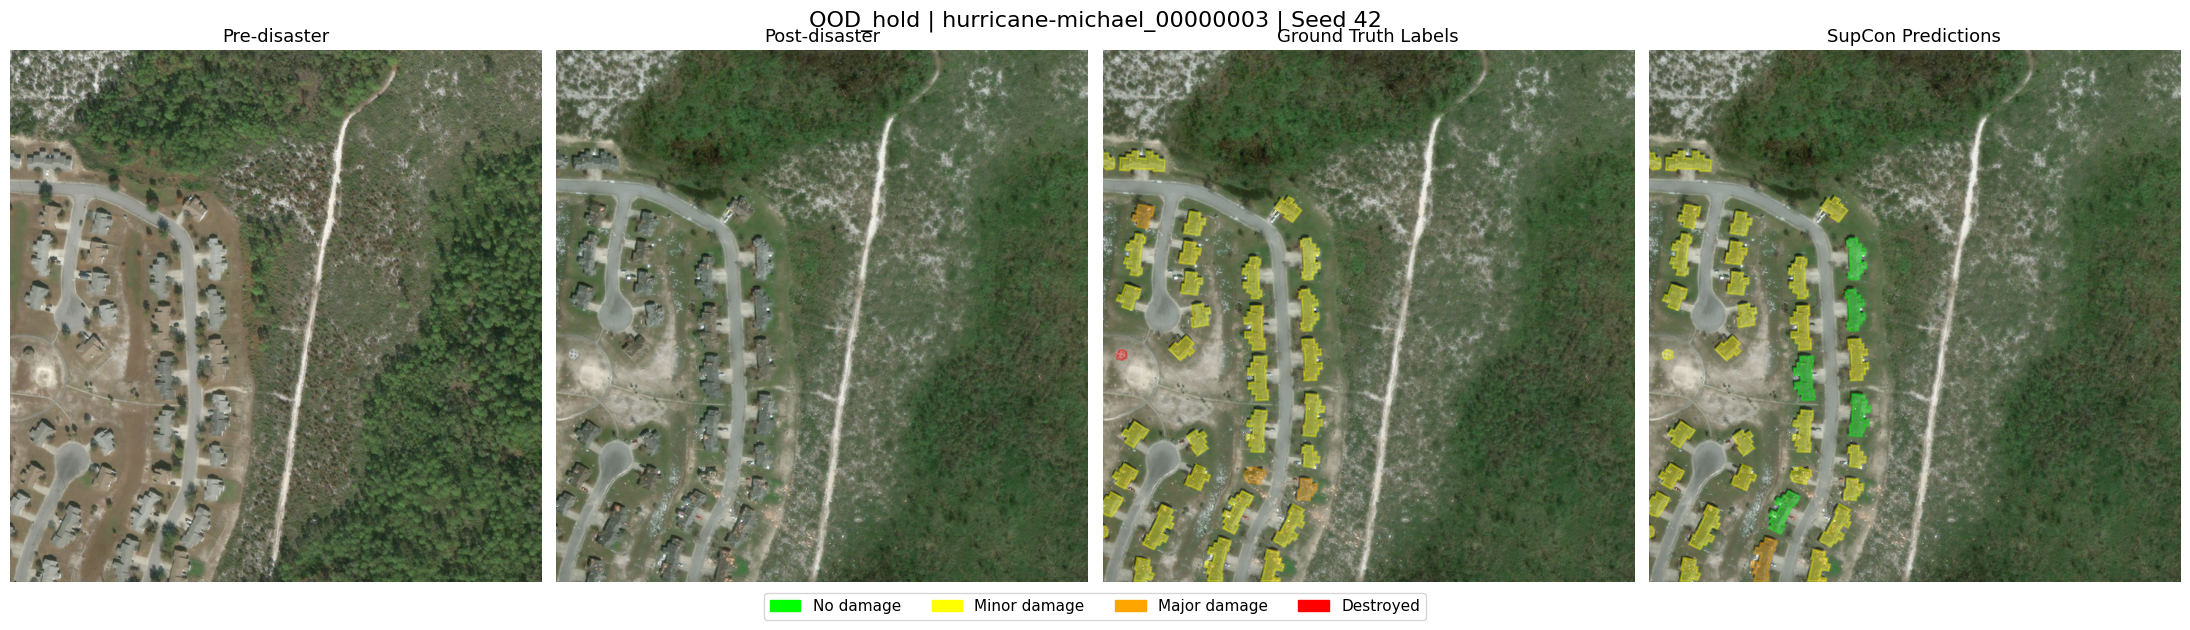

In [10]:
from pathlib import Path

import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely import wkt

# =========================
# Configuration
# =========================

SEED = 42
CSV_SPLIT = "OOD_hold"

BASE_DIR = Path.home() / "Desktop"

CSV_PATH = (
    BASE_DIR
    / "OOD_processed"
    / "buildings_all_OOD_with_crops.csv"
)

OUTPUT_DIR = (
    BASE_DIR
    / "OOD_training_outputs"
    / "unweighted_baseline_resnet50_5seeds_1se"
)

PRED_PATH = (
    OUTPUT_DIR
    / f"seed_{SEED}"
    / "ood_hold_predictions_selected_1se.csv"
)

LABELS = [
    "no-damage",
    "minor-damage",
    "major-damage",
    "destroyed",
]

COLORS = {
    "no-damage": "lime",
    "minor-damage": "yellow",
    "major-damage": "orange",
    "destroyed": "red",
}

# =========================
# Load data
# =========================

df = pd.read_csv(CSV_PATH)
pred_df = pd.read_csv(PRED_PATH)

print("Available splits:")
print(df["split"].value_counts())

split_df = df[df["split"] == CSV_SPLIT].copy().reset_index(drop=True)

print("\nRows in selected split:", len(split_df))
print("Rows in prediction file:", len(pred_df))

if len(split_df) == 0:
    raise ValueError(f"No rows found for split: {CSV_SPLIT}")

if len(split_df) != len(pred_df):
    raise ValueError(
        f"Mismatch: CSV split has {len(split_df)} rows, "
        f"but prediction file has {len(pred_df)} rows."
    )

# =========================
# Add predictions
# =========================

split_df["pred_idx"] = pred_df["pred_id"].values
split_df["true_idx"] = pred_df["target_id"].values

split_df["pred_label"] = split_df["pred_idx"].map(lambda i: LABELS[int(i)])
split_df["true_label"] = split_df["true_idx"].map(lambda i: LABELS[int(i)])

# =========================
# Select image
# =========================

counts = split_df["image_id"].value_counts()

print("\nNumber of available images:", len(counts))
print("\nFirst available image IDs:")
print(counts.head())

IMAGE_INDEX = 520

if IMAGE_INDEX >= len(counts):
    raise ValueError(
        f"IMAGE_INDEX={IMAGE_INDEX} is too large. "
        f"Maximum valid index is {len(counts) - 1}."
    )

image_id = counts.index[IMAGE_INDEX]
img_df = split_df[split_df["image_id"] == image_id].copy()

print("\nSelected image_id:", image_id)
print("Number of buildings in selected image:", len(img_df))

# =========================
# Load images
# =========================

pre_path = Path(img_df.iloc[0]["pre_image_path"])
post_path = Path(img_df.iloc[0]["post_image_path"])

if not pre_path.exists():
    raise FileNotFoundError(f"Missing pre-disaster image: {pre_path}")

if not post_path.exists():
    raise FileNotFoundError(f"Missing post-disaster image: {post_path}")

pre = np.array(Image.open(pre_path))
post = np.array(Image.open(post_path))

# =========================
# Plotting helper
# =========================

def draw_polygons(ax, image, rows, label_col, title):
    ax.imshow(image)
    ax.set_title(title, fontsize=13)
    ax.axis("off")

    for _, row in rows.iterrows():
        poly = wkt.loads(row["wkt"])
        label = row[label_col]
        color = COLORS[label]

        x, y = poly.exterior.xy
        coords = list(zip(x, y))

        patch = mpatches.Polygon(
            coords,
            closed=True,
            fill=True,
            alpha=0.35,
            edgecolor=color,
            facecolor=color,
            linewidth=1.5,
        )

        ax.add_patch(patch)

# =========================
# Legend
# =========================

legend_elements = [
    mpatches.Patch(color=COLORS["no-damage"], label="No damage"),
    mpatches.Patch(color=COLORS["minor-damage"], label="Minor damage"),
    mpatches.Patch(color=COLORS["major-damage"], label="Major damage"),
    mpatches.Patch(color=COLORS["destroyed"], label="Destroyed"),
]

# =========================
# Plot
# =========================

fig, axes = plt.subplots(1, 4, figsize=(22, 6))

axes[0].imshow(pre)
axes[0].set_title("Pre-disaster", fontsize=13)
axes[0].axis("off")

axes[1].imshow(post)
axes[1].set_title("Post-disaster", fontsize=13)
axes[1].axis("off")

draw_polygons(
    axes[2],
    post,
    img_df,
    label_col="true_label",
    title="Ground Truth Labels",
)

draw_polygons(
    axes[3],
    post,
    img_df,
    label_col="pred_label",
    title="SupCon Predictions",
)

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=4,
    bbox_to_anchor=(0.5, -0.05),
    fontsize=11,
)

plt.suptitle(
    f"{CSV_SPLIT} | {image_id} | Seed {SEED}",
    fontsize=16,
)

plt.tight_layout()
plt.show()

Using device: mps


/var/folders/bs/rzk6qg1902vgdlp6h22t8bq40000gn/T/ipykernel_41703/952652175.py:154: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), MAX_SAMPLES_PER_CLASS), random_state=SEED))


Samples used for t-SNE:
damage_label
major-damage    1000
minor-damage    1000
no-damage       1000
destroyed       1000
Name: count, dtype: int64
Loading checkpoint from: /Users/paolo/Desktop/OOD_training_outputs/unweighted_baseline_resnet50_5seeds_1se/seed_123/checkpoints/epoch_02.pt


Extracting Baseline encoder features:   0%|          | 0/63 [00:00<?, ?it/s]

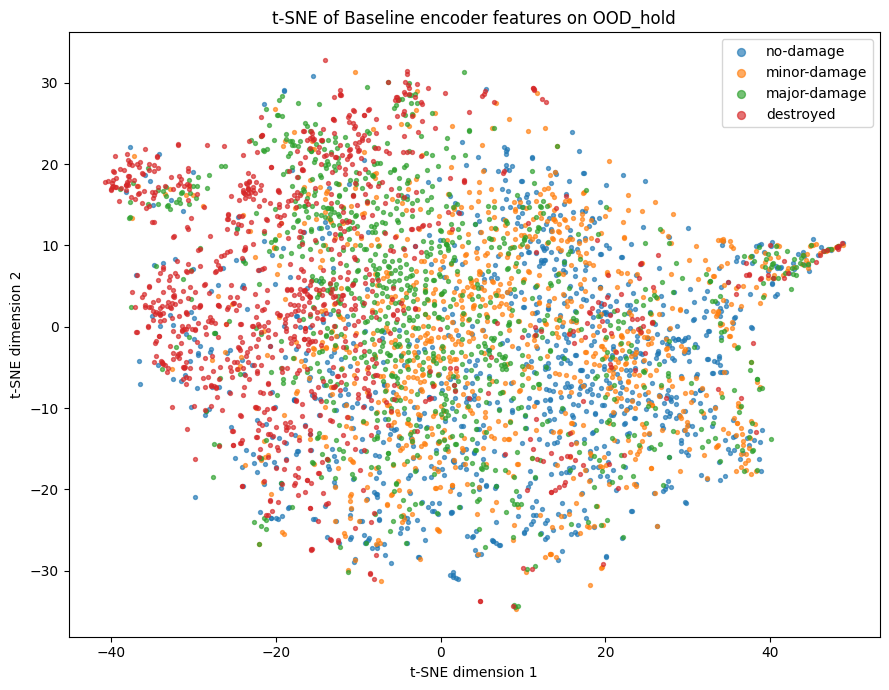

Saved CSV to: /Users/paolo/Desktop/OOD_training_outputs/unweighted_baseline_resnet50_5seeds_1se/tsne_outputs/baseline_tsne_seed_123_OOD_hold.csv
Saved figure to: /Users/paolo/Desktop/OOD_training_outputs/unweighted_baseline_resnet50_5seeds_1se/tsne_outputs/baseline_tsne_seed_123_OOD_hold.png


In [18]:
# =========================
# t-SNE for selected Baseline ResNet50 model
# Baseline checkpoint uses keys like backbone.conv1 and backbone.fc
# =========================

from pathlib import Path
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet50, ResNet50_Weights
from tqdm.auto import tqdm


BASE_DIR = Path.home() / "Desktop"
CSV_PATH = BASE_DIR / "OOD_processed" / "buildings_all_OOD_with_crops.csv"

OUTPUT_DIR = (
    BASE_DIR
    / "OOD_training_outputs"
    / "unweighted_baseline_resnet50_5seeds_1se"
)

TSNE_DIR = OUTPUT_DIR / "tsne_outputs"
TSNE_DIR.mkdir(parents=True, exist_ok=True)

SEED = 123
SELECTED_EPOCH = 2
SPLIT_TO_PLOT = "OOD_hold"

MAX_SAMPLES_PER_CLASS = 1000
BATCH_SIZE = 64
NUM_WORKERS = 0
FEATURE_DIM = 2048

LABEL_TO_IDX = {
    "no-damage": 0,
    "minor-damage": 1,
    "major-damage": 2,
    "destroyed": 3,
}

IDX_TO_LABEL = {v: k for k, v in LABEL_TO_IDX.items()}

IMAGENET_MEAN_6 = np.array(
    [0.485, 0.456, 0.406, 0.485, 0.456, 0.406],
    dtype=np.float32,
)

IMAGENET_STD_6 = np.array(
    [0.229, 0.224, 0.225, 0.229, 0.224, 0.225],
    dtype=np.float32,
)


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    else:
        return torch.device("cpu")


class XViewBuildingDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def normalize(self, x):
        return (x - IMAGENET_MEAN_6[:, None, None]) / IMAGENET_STD_6[:, None, None]

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        x = np.load(row["crop_path"])

        x = x.astype(np.float32) / 255.0
        x = np.transpose(x, (2, 0, 1))
        x = self.normalize(x)

        y = LABEL_TO_IDX[row["damage_label"]]

        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.long)


class BaselineResNet50SixChannel(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()

        weights = ResNet50_Weights.IMAGENET1K_V2
        self.backbone = resnet50(weights=weights)

        old_conv = self.backbone.conv1

        new_conv = nn.Conv2d(
            in_channels=6,
            out_channels=old_conv.out_channels,
            kernel_size=old_conv.kernel_size,
            stride=old_conv.stride,
            padding=old_conv.padding,
            bias=False,
        )

        with torch.no_grad():
            new_conv.weight[:, :3, :, :] = old_conv.weight * 0.5
            new_conv.weight[:, 3:, :, :] = old_conv.weight * 0.5

        self.backbone.conv1 = new_conv
        self.backbone.fc = nn.Linear(FEATURE_DIM, num_classes)

    def forward(self, x):
        return self.backbone(x)

    def extract_features(self, x):
        original_fc = self.backbone.fc
        self.backbone.fc = nn.Identity()

        features = self.backbone(x)

        self.backbone.fc = original_fc
        return features


set_seed(SEED)
device = get_device()

print(f"Using device: {device}")

df = pd.read_csv(CSV_PATH)
df = df[df["damage_label"].isin(LABEL_TO_IDX.keys())].copy()

plot_df = df[df["split"] == SPLIT_TO_PLOT].copy().reset_index(drop=True)

plot_df = (
    plot_df
    .groupby("damage_label", group_keys=False)
    .apply(lambda x: x.sample(n=min(len(x), MAX_SAMPLES_PER_CLASS), random_state=SEED))
    .sample(frac=1, random_state=SEED)
    .reset_index(drop=True)
)

print("Samples used for t-SNE:")
print(plot_df["damage_label"].value_counts())

loader = DataLoader(
    XViewBuildingDataset(plot_df),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

model = BaselineResNet50SixChannel(num_classes=4).to(device)

checkpoint_path = (
    OUTPUT_DIR
    / f"seed_{SEED}"
    / "checkpoints"
    / f"epoch_{SELECTED_EPOCH:02d}.pt"
)

print(f"Loading checkpoint from: {checkpoint_path}")

checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

features_all = []
labels_all = []

with torch.no_grad():
    for x, y in tqdm(loader, desc="Extracting Baseline encoder features"):
        x = x.to(device)
        features = model.extract_features(x)

        features_all.append(features.cpu().numpy())
        labels_all.append(y.numpy())

features = np.concatenate(features_all, axis=0)
labels = np.concatenate(labels_all, axis=0)

features_scaled = StandardScaler().fit_transform(features)

try:
    tsne = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate="auto",
        init="pca",
        random_state=SEED,
        max_iter=1000,
    )
except TypeError:
    tsne = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate="auto",
        init="pca",
        random_state=SEED,
        n_iter=1000,
    )

tsne_2d = tsne.fit_transform(features_scaled)

tsne_df = pd.DataFrame({
    "tsne_1": tsne_2d[:, 0],
    "tsne_2": tsne_2d[:, 1],
    "label_id": labels,
    "label": [IDX_TO_LABEL[int(y)] for y in labels],
})

csv_path = TSNE_DIR / f"baseline_tsne_seed_{SEED}_{SPLIT_TO_PLOT}.csv"
png_path = TSNE_DIR / f"baseline_tsne_seed_{SEED}_{SPLIT_TO_PLOT}.png"

tsne_df.to_csv(csv_path, index=False)

plt.figure(figsize=(9, 7))

for label_id, label_name in IDX_TO_LABEL.items():
    subset = tsne_df[tsne_df["label_id"] == label_id]

    plt.scatter(
        subset["tsne_1"],
        subset["tsne_2"],
        s=8,
        alpha=0.65,
        label=label_name,
    )

plt.title(f"t-SNE of Baseline encoder features on {SPLIT_TO_PLOT}")
plt.xlabel("t-SNE dimension 1")
plt.ylabel("t-SNE dimension 2")
plt.legend(markerscale=2)
plt.tight_layout()
plt.savefig(png_path, dpi=300)
plt.show()

print(f"Saved CSV to: {csv_path}")
print(f"Saved figure to: {png_path}")